# EDA - Série Histórica de Preços de Combustíveis e de GLP

"Em cumprimento às determinações da Lei do Petróleo (Lei nº 9478/1997, artigo 8º), a ANP acompanha os preços praticados por revendedores de combustíveis automotivos e de gás liquefeito de petróleo envasilhado em botijões de 13 quilos (GLP P13), por meio de uma pesquisa semanal de preços realizada por empresa contratada.

Veja abaixo os resultados das pesquisas que compõem a Série Histórica de Preços de Combustíveis (arquivos em formato .csv)."

* site: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis
* Nessa análise exploratória, vou abordar o **1º semestre de 2025**.

# 1) Entendimento inicial do dado

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Preços semestrais - AUTOMOTIVOS_2025.01.csv", sep = ";", skip_blank_lines=True)
df.head()

C:\Users\leomi\AppData\Local\Temp\ipykernel_3260\1852004862.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Preços semestrais - AUTOMOTIVOS_2025.01.csv", sep = ";", skip_blank_lines=True)


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,NaN,CENTRO,62010-000,GASOLINA,01/01/2025,"6,29",NaN,R$ / litro,RAIZEN
1,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,NaN,CENTRO,62010-000,GASOLINA ADITIVADA,01/01/2025,"6,49",NaN,R$ / litro,RAIZEN
2,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,NaN,CENTRO,62010-000,DIESEL S10,01/01/2025,"6,19",NaN,R$ / litro,RAIZEN
3,NE,CE,SOBRAL,ECONOGÁS DO BRASIL DIST. DERIV. DE PET. BIOC. ...,08.775.979/0002-62,RUA TABELIÃO IDELFONSO CAVALCANTI,455,NaN,CENTRO,62010-000,ETANOL,01/01/2025,"5,19",NaN,R$ / litro,RAIZEN
4,NE,CE,SOBRAL,V.C.EMPREENDIMENTOS LTDA,03.551.935/0002-35,AVENIDA JOSE EUCLIDES FERREIRA GOMES,30,POSTO FLASH,CORACAO DE JESUS,62043-070,GASOLINA,01/01/2025,"6,53",NaN,R$ / litro,RAIZEN


In [3]:
df.tail(20)

,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
429503,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
429512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* Há muitas linhas com todas entradas nulas no final do dataset

In [4]:
#Conhecer as colunas
df.columns

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira'],
      dtype='object')

In [5]:
#dimensão do dado
df.shape

(429523, 16)

Verificando quais Unidades de Medidas foram usadas

In [6]:
df["Unidade de Medida"].value_counts(dropna=True)

Unidade de Medida
R$ / litro    410901
R$ / m³         9508
Name: count, dtype: int64

* Será interessante padronizar algumas colunas

In [7]:
# Conhecer os produtos
df["Produto"].value_counts(dropna=True)

Produto
GASOLINA              110818
ETANOL                 92598
GASOLINA ADITIVADA     85580
DIESEL S10             76134
DIESEL                 45771
GNV                     9508
Name: count, dtype: int64

In [8]:
#Informações
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429523 entries, 0 to 429522
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Regiao - Sigla     420409 non-null  object 
 1   Estado - Sigla     420409 non-null  object 
 2   Municipio          420409 non-null  object 
 3   Revenda            420409 non-null  object 
 4   CNPJ da Revenda    420409 non-null  object 
 5   Nome da Rua        420409 non-null  object 
 6   Numero Rua         420351 non-null  object 
 7   Complemento        96615 non-null   object 
 8   Bairro             419547 non-null  object 
 9   Cep                420409 non-null  object 
 10  Produto            420409 non-null  object 
 11  Data da Coleta     420409 non-null  object 
 12  Valor de Venda     420409 non-null  object 
 13  Valor de Compra    0 non-null       float64
 14  Unidade de Medida  420409 non-null  object 
 15  Bandeira           420409 non-null  object 
dtypes:

* Coluna *"Valor de Compra"* possui apenas entradas nulas. No nosso caso vamos apenas excluir essa coluna na nossa análise.
* *"Valor de Venda"* está como object. Vamos converter em float para poder estudar métricas.
* Vamos converter *"Data da Coleta"* em tipo data.

# 2) Ajustes no dado

Vamos realizar os seguintes tratamentos:
* *"Valor de Venda"* : object $\rightarrow$ float.
* *"Data da Coleta"* : object $\rightarrow$ data.
* Excluir linhas com todas entradas nulas

In [9]:
df["Valor de Venda"] = (
    df["Valor de Venda"].astype(str)
    .str.replace(".", "", regex=False)   # remove separador de milhar
    .str.replace(",", ".", regex=False)  # vírgula -> ponto
)
df["Valor de Venda"] = pd.to_numeric(df["Valor de Venda"], errors="coerce")

# 2) "Data da Coleta": object -> datetime
df["Data da Coleta"] = pd.to_datetime(df["Data da Coleta"], dayfirst=True, errors="coerce").dt.date

# 3) Excluir linhas com todas as entradas nulas
df = df.dropna(how="all")

In [10]:
#Checagem
    ## Conversão ok
    ## Linhas todas nulas eliminadas
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420409 entries, 0 to 420408
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Regiao - Sigla     420409 non-null  object 
 1   Estado - Sigla     420409 non-null  object 
 2   Municipio          420409 non-null  object 
 3   Revenda            420409 non-null  object 
 4   CNPJ da Revenda    420409 non-null  object 
 5   Nome da Rua        420409 non-null  object 
 6   Numero Rua         420351 non-null  object 
 7   Complemento        96615 non-null   object 
 8   Bairro             419547 non-null  object 
 9   Cep                420409 non-null  object 
 10  Produto            420409 non-null  object 
 11  Data da Coleta     420409 non-null  object 
 12  Valor de Venda     420409 non-null  float64
 13  Valor de Compra    0 non-null       float64
 14  Unidade de Medida  420409 non-null  object 
 15  Bandeira           420409 non-null  object 
dtypes: floa

In [11]:
df.describe()

,Valor de Venda,Valor de Compra
count,420409.000000,0.0
mean,5.890884,NaN
std,0.893260,NaN
min,3.190000,NaN
25%,5.590000,NaN
50%,6.170000,NaN
75%,6.490000,NaN
max,9.490000,NaN


Convertendo para mesma Unidade de Medida

In [12]:
# construir uma máscara para linhas em m³
    ## Criar série booleana de True/False
mask_m3 = df["Unidade de Medida"].str.contains(r"m³", case=False, na=False)

# converter apenas quem está em m³ -> R$ / litro
df.loc[mask_m3, "Valor de Venda"] = df.loc[mask_m3, "Valor de Venda"] / 1000.0

# padronizar o texto da unidade para todas as linhas
df.loc[mask_m3, "Unidade de Medida"] = "R$ / litro"
df.loc[~mask_m3 & df["Unidade de Medida"].notna(), "Unidade de Medida"] = "R$ / litro"

In [13]:
df["Valor de Venda"] = df["Valor de Venda"].round(3)

In [14]:
#Checagem
df["Unidade de Medida"].value_counts(dropna=True)

Unidade de Medida
R$ / litro    420409
Name: count, dtype: int64

In [40]:
#linhas duplicadas - linhas duplicadas prováveis (mesmo posto, mesmo produto, mesma data)
chaves = ["CNPJ da Revenda", "Nome da Rua", "Bairro", "Município", "Estado - Sigla", "Produto", "Data da Coleta"]
dup_mask = df.duplicated(subset=[c for c in chaves if c in df.columns], keep=False)
print(f"Duplicados potenciais: {dup_mask.sum()} ({dup_mask.mean():.1%})")

Duplicados potenciais: 0 (0.0%)


In [38]:
#outliers
# IQR por UF x Produto
grp = df.groupby(["Estado - Sigla", "Produto"])["Valor de Venda"]
q1 = grp.quantile(0.25)
q3 = grp.quantile(0.75)
iqr = q3 - q1
bounds = pd.concat([q1 - 1.5*iqr, q3 + 1.5*iqr], axis=1)
bounds.columns = ["low", "high"]

def flag_outlier(row):
    key = (row["Estado - Sigla"], row["Produto"])
    if key in bounds.index:
        lo, hi = bounds.loc[key, ["low","high"]]
        v = row["Valor de Venda"]
        return (v < lo) or (v > hi)
    return False

df["is_outlier"] = df.apply(flag_outlier, axis=1)

print("Outliers detectados:", df["is_outlier"].sum(), f"({df['is_outlier'].mean():.2%})")

# comparação: média/mediana com e sem outliers
comp = (
    df.groupby(["Estado - Sigla","Produto"])
      .apply(lambda g: pd.Series({
          "media_bruta": g["Valor de Venda"].mean(),
          "mediana_bruta": g["Valor de Venda"].median(),
          "media_sem_outlier": g.loc[~g["is_outlier"], "Valor de Venda"].mean(),
          "mediana_sem_outlier": g.loc[~g["is_outlier"], "Valor de Venda"].median(),
          "cv_sem_outlier": g.loc[~g["is_outlier"], "Valor de Venda"].std(ddof=0) / g.loc[~g["is_outlier"], "Valor de Venda"].mean()
      }))
)
comp.head()


Outliers detectados: 9113 (2.17%)


C:\Users\leomi\AppData\Local\Temp\ipykernel_3260\2806666878.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


media_bruta  mediana_bruta  \
Estado - Sigla Produto                                          
AC             DIESEL                 7.848428           7.79   
               DIESEL S10             7.924195           7.93   
               ETANOL                 5.469960           5.39   
               GASOLINA               7.733930           7.65   
               GASOLINA ADITIVADA     7.763806           7.69   

                                   media_sem_outlier  mediana_sem_outlier  \
Estado - Sigla Produto                                                      
AC             DIESEL                       7.848428                 7.79   
               DIESEL S10                   7.924195                 7.93   
               ETANOL                       5.425641                 5.34   
               GASOLINA                     7.733930                 7.65   
               GASOLINA ADITIVADA           7.763806                 7.69   

                                   cv_sem_outlier  
Estado - Sigla Produto                             
AC             DIESEL                    0.034779  
               DIESEL S10                0.033122  
               ETANOL                    0.047964  
               GASOLINA                  0.033111  
               GASOLINA ADITIVADA        0.032136

# 3) Reflexões e perguntas de negócio

### Onde está mais barato?

Index(['Regiao - Sigla', 'Estado - Sigla', 'Municipio', 'Revenda',
       'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua', 'Complemento', 'Bairro',
       'Cep', 'Produto', 'Data da Coleta', 'Valor de Venda', 'Valor de Compra',
       'Unidade de Medida', 'Bandeira']

Preço médio dos combustíveis por **Estado**

In [33]:
df.groupby(["Estado - Sigla"])[["Valor de Venda"]].mean().sort_values(by="Valor de Venda", ascending = False)

,Valor de Venda
Estado - Sigla,
AC,7.423546
RR,6.839685
AM,6.757587
RO,6.728150
PA,6.370388
AP,6.238248
DF,6.148812
TO,6.052966
RS,6.046999


* Preços mais altos nas regiões Norte e algumas do Nordeste. Será que tem relação com o custo do transporte de combustível?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

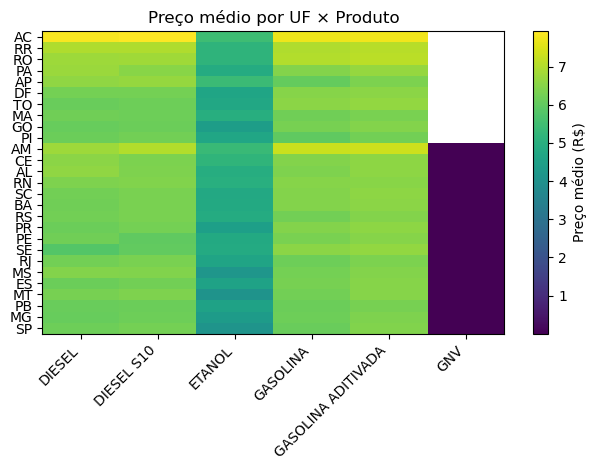

In [36]:
# tabela UF x Produto com a MÉDIA (MAPA DE CALOR)
tab = (df.groupby(["Estado - Sigla","Produto"])["Valor de Venda"]
         .mean().unstack("Produto"))

# ordem: estados pelo preço médio geral
tab = tab.loc[tab.mean(axis=1).sort_values(ascending=False).index]

plt.figure()
im = plt.imshow(tab.values, aspect="auto")
plt.colorbar(im, label="Preço médio (R$)")
plt.xticks(ticks=np.arange(tab.shape[1]), labels=tab.columns, rotation=45, ha="right")
plt.yticks(ticks=np.arange(tab.shape[0]), labels=tab.index)
plt.title("Preço médio por UF × Produto")
plt.tight_layout()
plt.show()


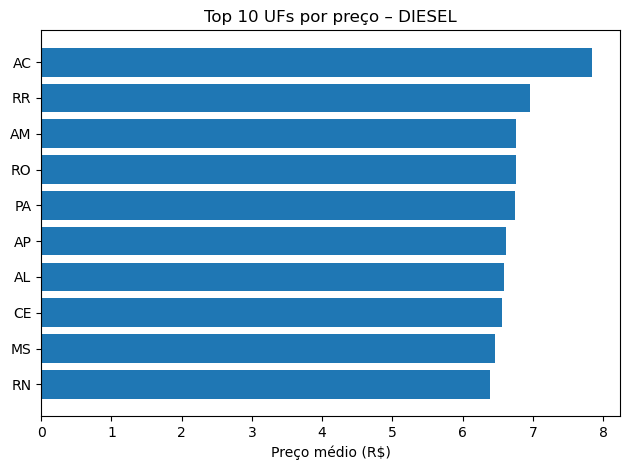

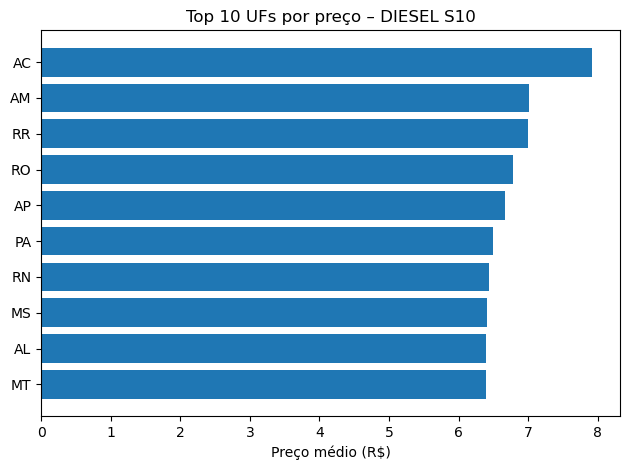

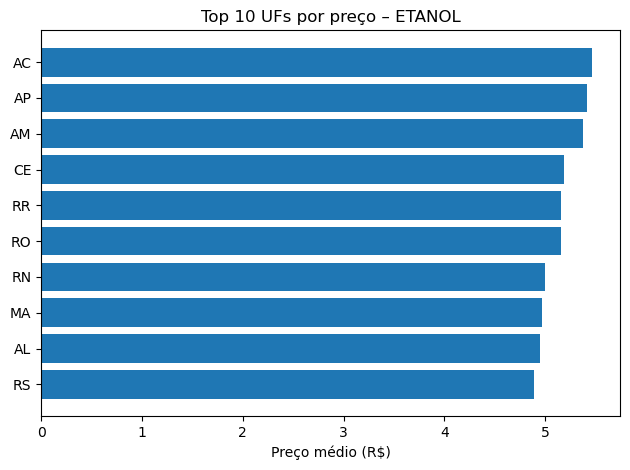

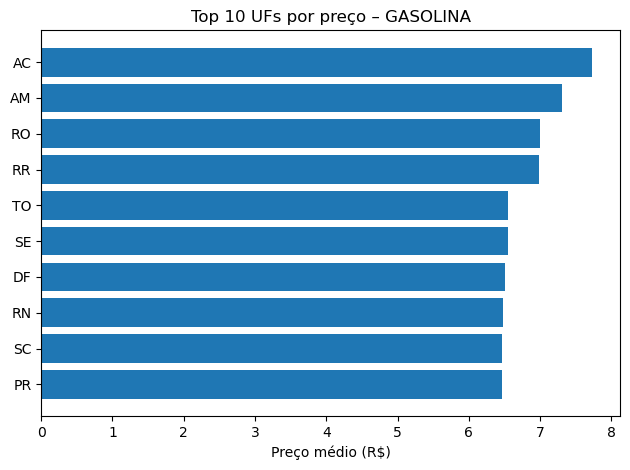

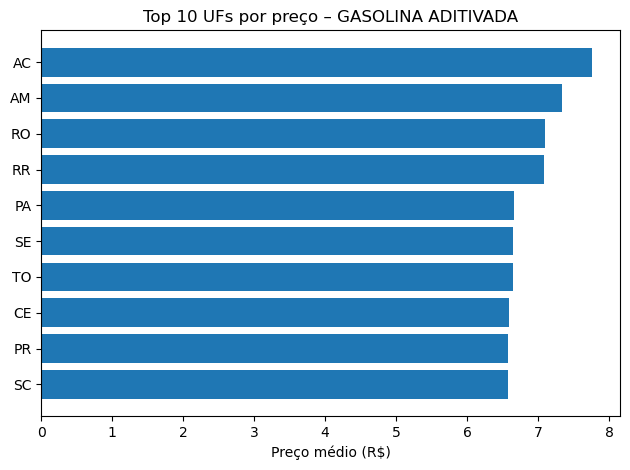

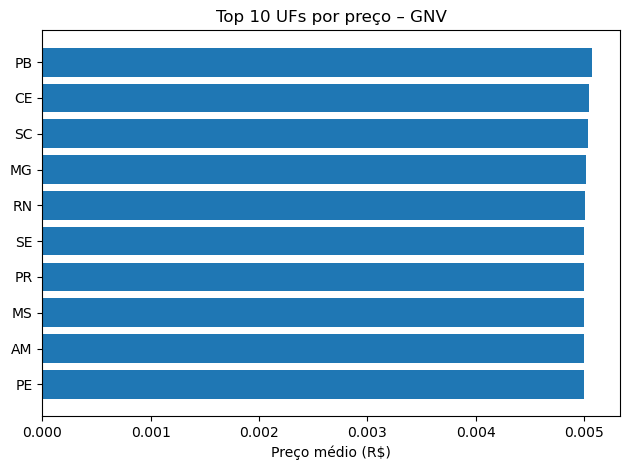

In [37]:
#TOP 10 Estados x combustível mais caros
N = 10  # top N por produto
g = (df.groupby(["Estado - Sigla","Produto"])["Valor de Venda"]
       .mean().reset_index())

for prod, d in g.groupby("Produto"):
    d2 = d.sort_values("Valor de Venda", ascending=False).head(N)
    plt.figure()
    plt.barh(d2["Estado - Sigla"], d2["Valor de Venda"])
    plt.gca().invert_yaxis()
    plt.xlabel("Preço médio (R$)")
    plt.title(f"Top {N} UFs por preço – {prod}")
    plt.tight_layout()
    plt.show()


In [35]:
df.groupby(["Estado - Sigla","Produto"])[["Valor de Venda"]].mean()

Valor de Venda
Estado - Sigla Produto                           
AC             DIESEL                    7.848428
               DIESEL S10                7.924195
               ETANOL                    5.469960
               GASOLINA                  7.733930
               GASOLINA ADITIVADA        7.763806
...                                           ...
TO             DIESEL                    6.123497
               DIESEL S10                6.166811
               ETANOL                    4.764948
               GASOLINA                  6.550886
               GASOLINA ADITIVADA        6.639803

[152 rows x 1 columns]

### Dispersão dos preços
* IQR (Q3−Q1): robusto a extremos; mostra a “largura do meio” da distribuição (50% central).

* Amplitude (max−min): sensível a outliers; dá noção do pior/melhor preço observado.

* CV (std/média): dispersão relativa (%), útil para comparar produtos com níveis de preço diferentes.

In [47]:
disp = (
    base.groupby(["Estado - Sigla","Produto"])["Valor de Venda"]
        .agg(q1=lambda x: x.quantile(0.25),
             q3=lambda x: x.quantile(0.75),
             mediana="median", media="mean", dp="std", n="count",
             minimo="min", maximo="max")
)

disp["iqr"] = disp["q3"] - disp["q1"]
disp["amplitude"] = disp["maximo"] - disp["minimo"]
disp["cv"] = disp["dp"] / disp["media"]

# exemplo de leitura: top 10 UFs com maior iqr para Gasolina Comum
alvo = "GASOLINA"
print(f"Disperção: {alvo}")
print(
    disp.xs(alvo, level="Produto")
        .sort_values("iqr", ascending=False)
        .head(10)[["mediana","iqr","amplitude","cv","n"]]
)


Disperção: GASOLINA
                mediana     iqr  amplitude        cv      n
Estado - Sigla                                             
PA                 6.39  0.7600       2.05  0.070210   2830
MS                 6.29  0.6000       1.66  0.067891   1429
MA                 6.20  0.6000       1.82  0.067550   2584
RJ                 6.19  0.5900       2.30  0.051377   8488
PE                 6.39  0.5800       2.14  0.054029   4566
AC                 7.65  0.4700       1.00  0.033156    374
PR                 6.39  0.4600       1.44  0.049320   6833
MT                 6.19  0.4100       1.23  0.046650   1988
ES                 6.29  0.4075       1.42  0.047470   2418
SP                 6.09  0.4000       1.60  0.047188  29406


* PA: IQR 0,76 (maior da sua amostra) e amplitude 2,05 com CV 7,0% $\rightarrow$ alta heterogeneidade de preços dentro do estado. Amplitude grande reforça cauda longa/extremos.

* MS/MA/PE/RJ: IQR 0,58–0,60 e CV ~5–6,8% $\rightarrow$ também dispersos. RJ chama atenção pela maior amplitude (2,30); mesmo com CV “apenas” 5,1%, o range sugere extremos relevantes.

* PR/MT/ES/SP: IQR 0,40–0,46, CV ~4,6–4,9% → dispersão moderada.

* AC: nível alto (mediana 7,65), mas CV 3,3% e amplitude 1,00 $\rightarrow$ preços caros porém mais alinhados (homogêneos) no estado.

### Série histórica do preço médio mensal de cada combustível por UF

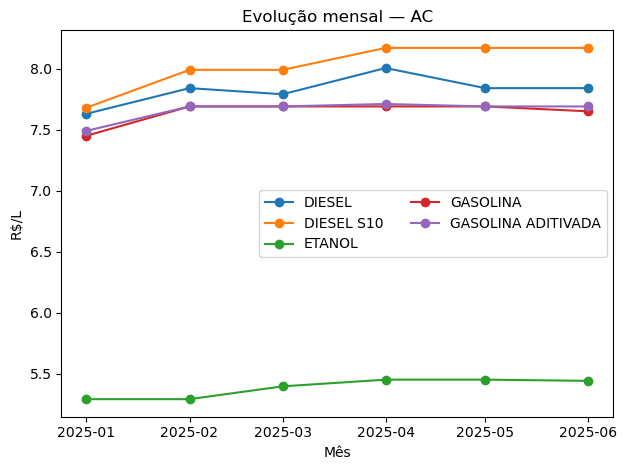

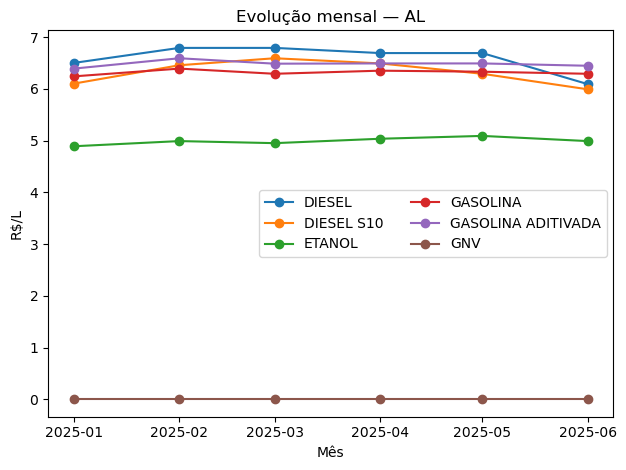

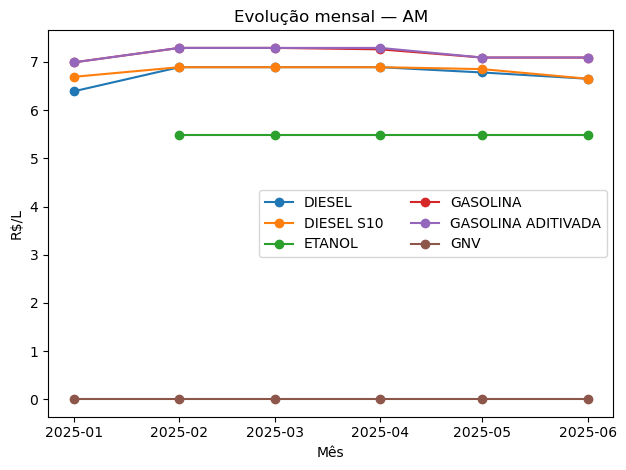

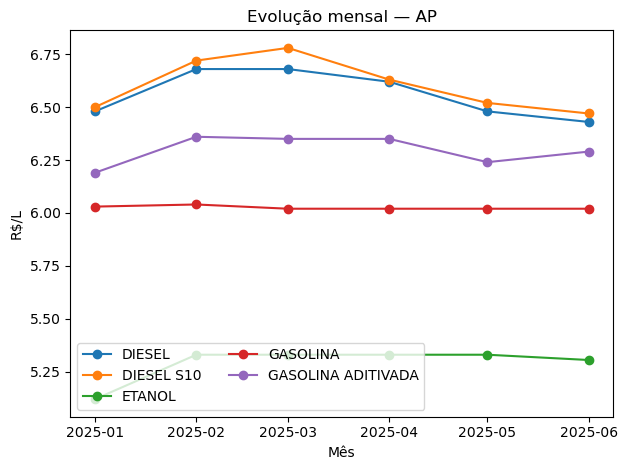

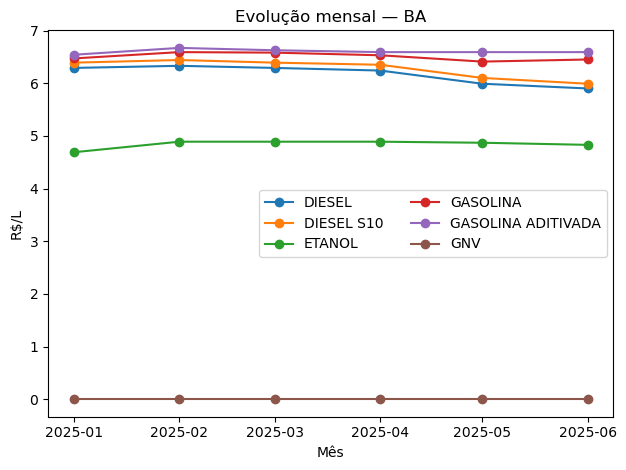

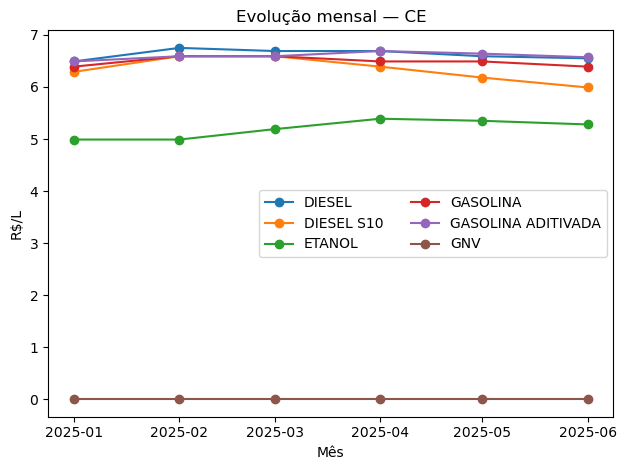

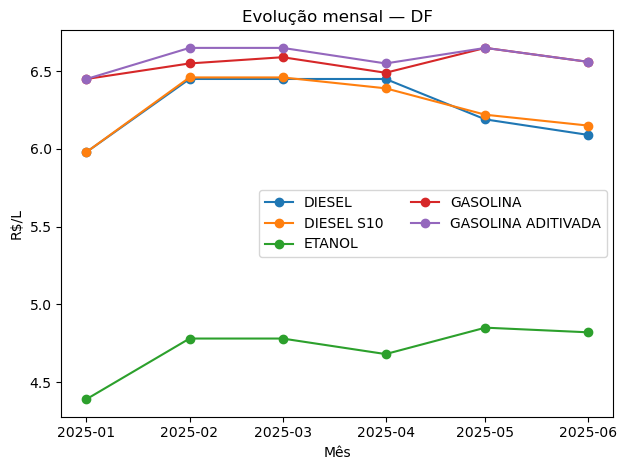

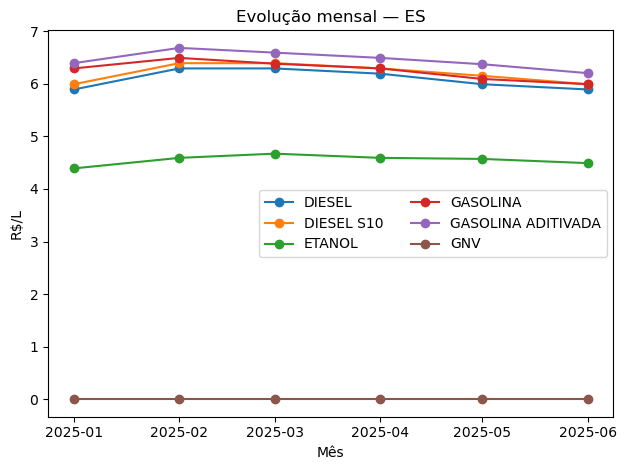

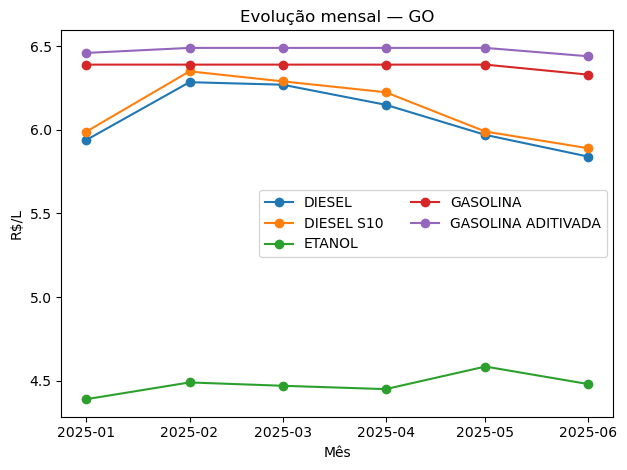

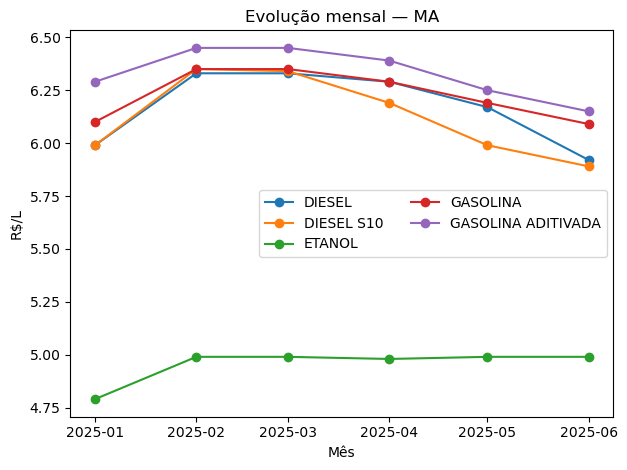

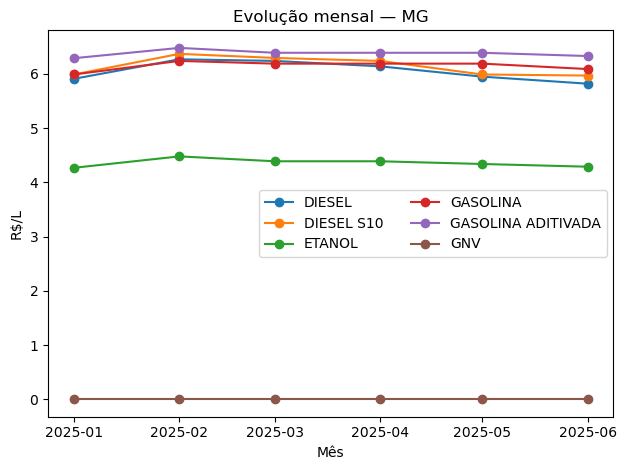

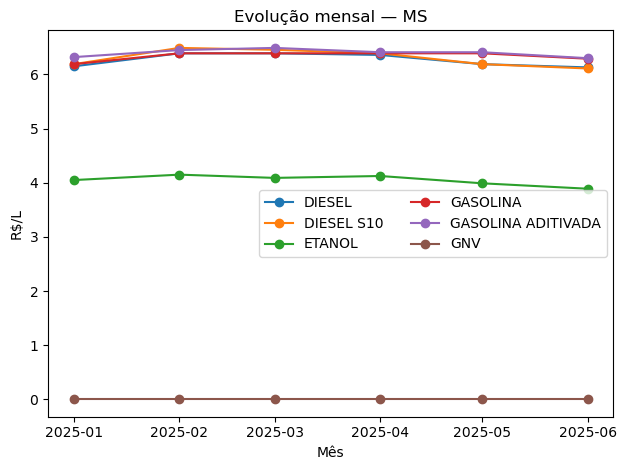

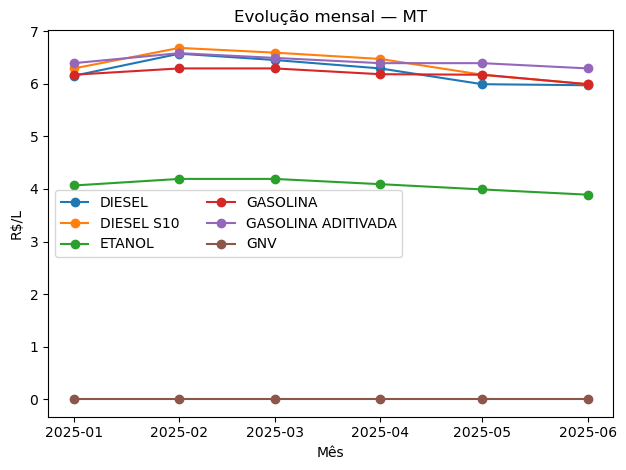

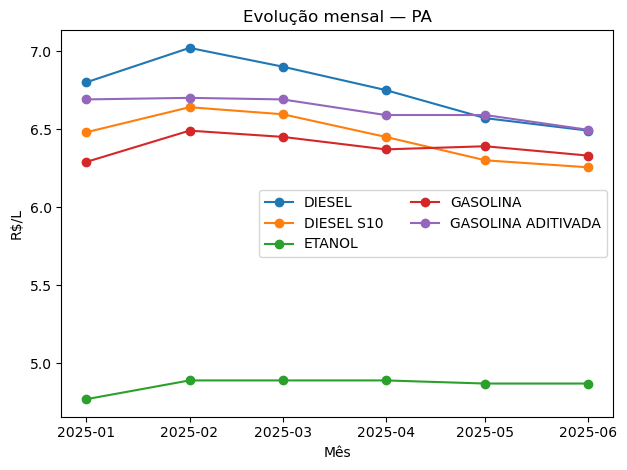

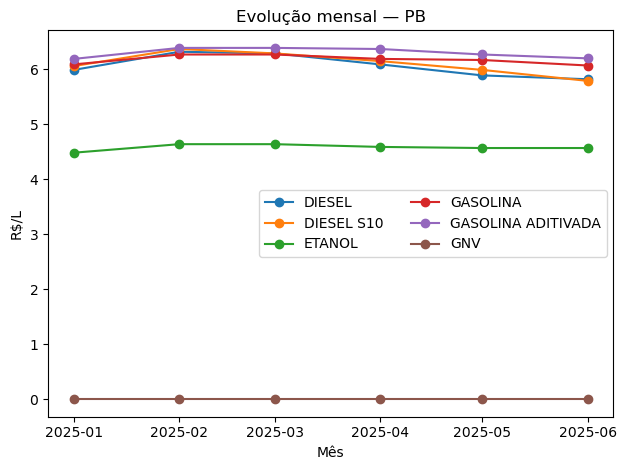

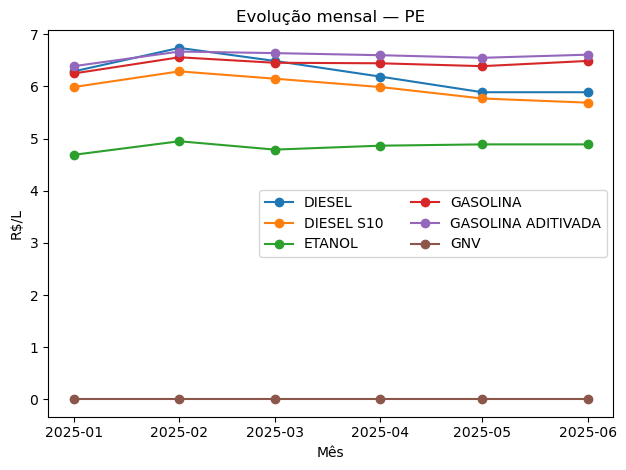

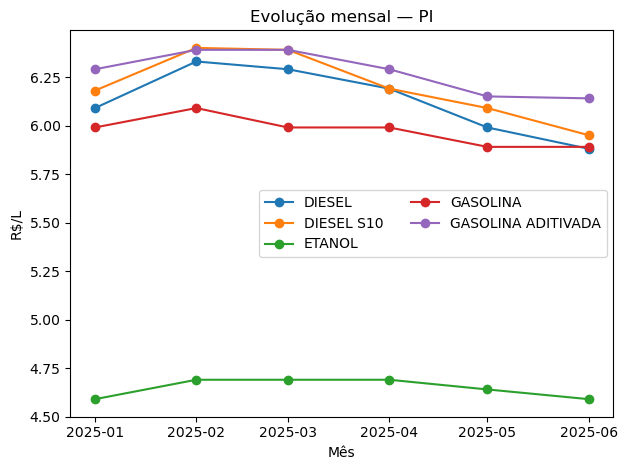

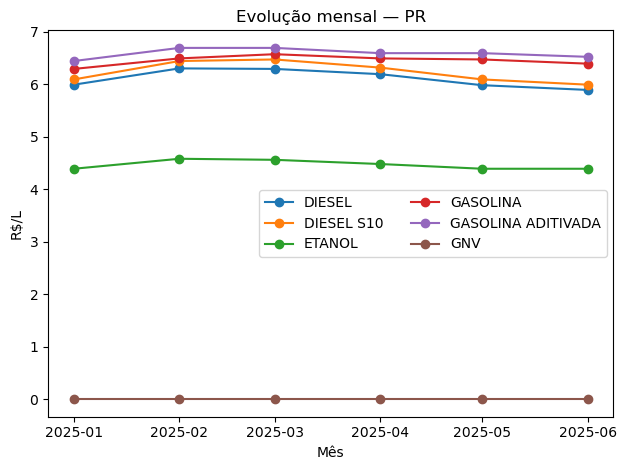

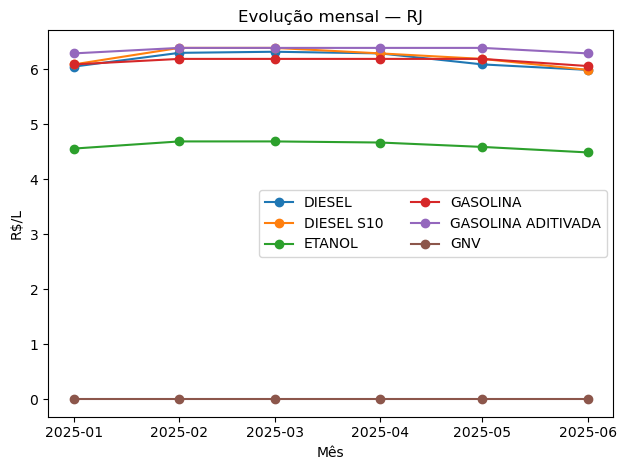

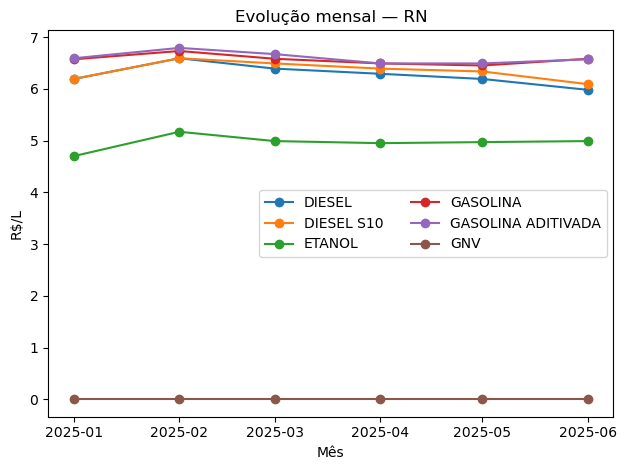

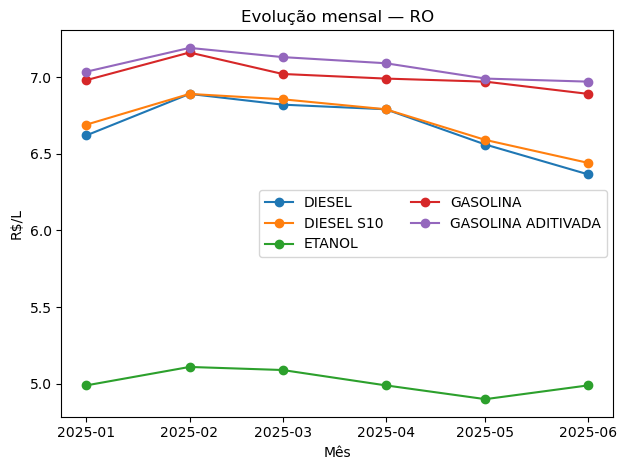

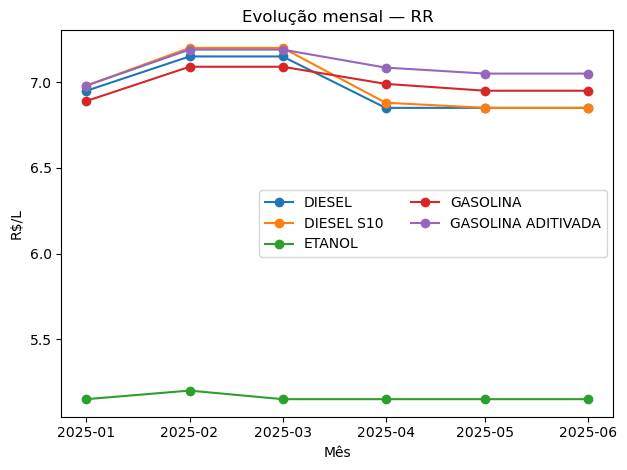

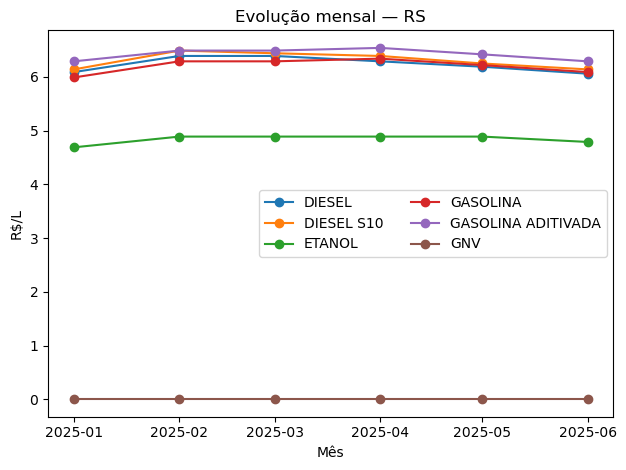

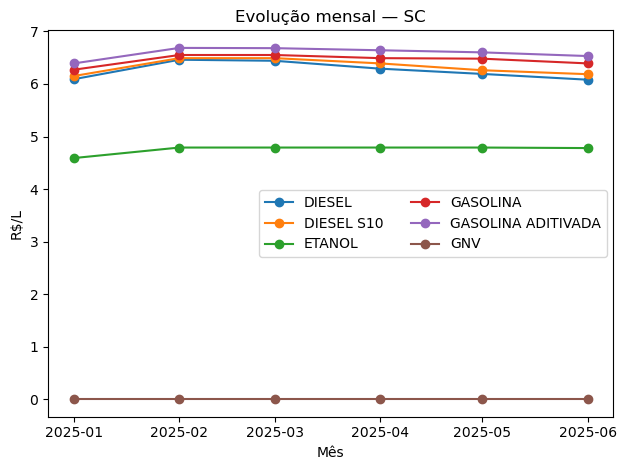

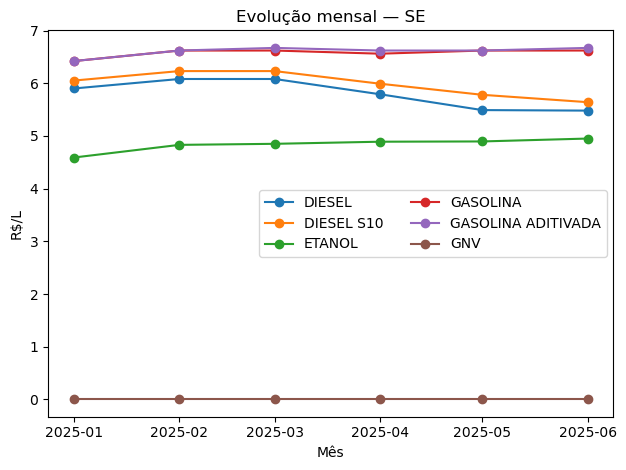

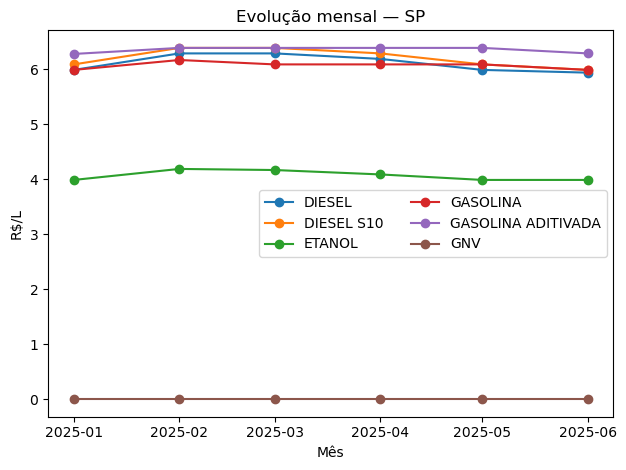

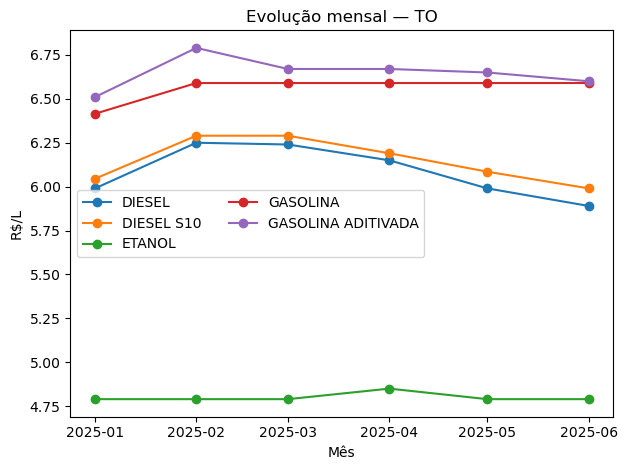

In [51]:
base = df if "is_outlier" not in df.columns else df[~df["is_outlier"]]
base = base.copy()
base["Data da Coleta"] = pd.to_datetime(base["Data da Coleta"])
base["mes"] = base["Data da Coleta"].dt.to_period("M").dt.to_timestamp()

min_obs_prod = 500   
produtos_validos = (base.groupby("Produto").size()
                        .loc[lambda s: s>=min_obs_prod].index)
base = base[base["Produto"].isin(produtos_validos)]

monthly = (base.groupby(["mes","Estado - Sigla","Produto"])["Valor de Venda"]
                .median()
                .reset_index()
                .sort_values("mes"))

ufs = monthly["Estado - Sigla"].dropna().unique()

for uf in sorted(ufs):
    aux = monthly[monthly["Estado - Sigla"]==uf]
    produtos = aux["Produto"].unique()

    plt.figure()
    for p in sorted(produtos):
        s = aux[aux["Produto"]==p].set_index("mes")["Valor de Venda"]
        plt.plot(s.index, s.values, marker="o", label=p)  # marcador ajuda em mensal
    plt.title(f"Evolução mensal — {uf}")
    plt.xlabel("Mês"); plt.ylabel("R$/L"); plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 4) Perguntas de negócio

### Pergunta: Em cada município, como o nível de preço de cada posto (ou do estado) se posiciona no percentil local?

In [53]:
base = df.copy()
base["Data da Coleta"] = pd.to_datetime(base["Data da Coleta"])

col_posto = "CNPJ da Revenda" if "CNPJ da Revenda" in base.columns else None
grupo_local = ["Estado - Sigla", "Municipio", "Produto"]

# percentil do preço de cada observação dentro do seu mercado local (município × produto)
def pct_rank(x):
    # rank de percentil (0-100)
    return 100 * x.rank(pct=True, method="average")

base["pct_local"] = base.groupby(grupo_local)["Valor de Venda"].transform(pct_rank)

# resumo por posto (se existir) ou por município
if col_posto:
    pos = (base.groupby(grupo_local + [col_posto])["pct_local"]
              .median().reset_index().rename(columns={"pct_local":"pct_median"}))
else:
    pos = (base.groupby(grupo_local)["pct_local"]
              .median().reset_index().rename(columns={"pct_local":"pct_median"}))

# TOPs caros (pct_local alto) e baratos (pct_local baixo)
top_caros = pos.sort_values("pct_median", ascending=False).head(15)
top_baratos = pos.sort_values("pct_median", ascending=True).head(15)
print("Mais CAROS no mercado local:\n", top_caros)
print("\nMais BARATOS no mercado local:\n", top_baratos)


Mais CAROS no mercado local:
       Estado - Sigla       Municipio             Produto      CNPJ da Revenda  \
3720              ES        LINHARES              DIESEL   13.602.147/0001-01   
5434              MA  BARRA DO CORDA              ETANOL   09.418.503/0002-37   
24111             SP         ITAPIRA  GASOLINA ADITIVADA   59.253.898/0001-52   
24106             SP         ITAPIRA            GASOLINA   59.253.898/0001-52   
24100             SP         ITAPIRA              ETANOL   59.253.898/0001-52   
24090             SP         ITAPIRA              DIESEL   02.656.787/0001-70   
20952             SC         XANXERE              ETANOL   02.291.838/0001-07   
20941             SC         XANXERE              DIESEL   83.854.943/0001-09   
3674              ES       GUARAPARI              DIESEL   10.405.989/0001-77   
23914             SP      INDAIATUBA            GASOLINA   62.393.897/0001-18   
23938             SP      INDAIATUBA  GASOLINA ADITIVADA   62.393.897/0001-18  

### Pergunta: Quais mercados possuem preços parecidos e quais possuem muita variação?

In [56]:
base = df.copy()
min_obs = 30

disp_mun = (base.groupby(["Estado - Sigla","Municipio","Produto"])["Valor de Venda"]
                 .agg(n="count", mediana="median",
                      q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
                      dp="std", minimo="min", maximo="max")
                 .reset_index())
disp_mun = disp_mun[disp_mun["n"]>=min_obs]
disp_mun["iqr"] = disp_mun["q3"] - disp_mun["q1"]
disp_mun["cv"] = disp_mun["dp"] / disp_mun["mediana"].replace(0, np.nan)
disp_mun["amplitude"] = disp_mun["maximo"] - disp_mun["minimo"]

print("Mercados MAIS DISPERSOS (por IQR):")
print(disp_mun.sort_values(["Produto","iqr"], ascending=[True,False]).groupby("Produto").head(10)
      [["Estado - Sigla","Municipio","mediana","iqr","cv","amplitude","n"]])


Mercados MAIS DISPERSOS (por IQR):
     Estado - Sigla              Municipio  mediana     iqr        cv  \
2096             SP        TABOAO DA SERRA    6.350  1.9000  0.147347   
1751             SP                DIADEMA    6.890  1.1800  0.088261   
788              PA               ALTAMIRA    6.850  0.9600  0.069318   
1676             SP                BARUERI    6.150  0.9550  0.083490   
1746             SP                CUBATAO    6.890  0.9500  0.075331   
2023             SP                 SANTOS    6.490  0.9125  0.074102   
1671             SP               BARRETOS    6.690  0.9000  0.071288   
106              BA                  IPIRA    6.190  0.8600  0.073656   
1814             SP                ITAPEVA    6.390  0.8400  0.079328   
763              MT                  SINOP    6.490  0.7750  0.071075   
1677             SP                BARUERI    6.390  1.1000  0.139375   
945              PE              SALGUEIRO    5.890  1.0800  0.092231   
1752            

### Pergunta: Em quais UFs/municípios o etanol compensa (Etanol/Gasolina < 0,70) e com que frequência?

Obteremos a proporção de (Data, Município) da UF com Etanol < 70% do preço da Gasolina.

In [58]:
base = df.copy()
base["Data da Coleta"] = pd.to_datetime(base["Data da Coleta"])

# mediana diária por produto
daily = (base.groupby(["Data da Coleta","Estado - Sigla","Municipio","Produto"])["Valor de Venda"]
             .median().unstack("Produto"))

ok_cols = {"GASOLINA","ETANOL"}.intersection(set(daily.columns))
if ok_cols == {"GASOLINA","ETANOL"}:
    daily["paridade"] = daily["ETANOL"] / daily["GASOLINA"]
    # % de dias com paridade < 0,70 por UF (ou município)
    resumo_uf = (daily.reset_index()
                      .groupby(["Estado - Sigla"])["paridade"]
                      .apply(lambda s: (s<0.70).mean())
                      .sort_values(ascending=False)
                      .to_frame("pct_dias_baixo_0p70"))
    print(resumo_uf.head(15))
else:
    print("Colunas de Gasolina e Etanol não estão ambas presentes para calcular paridade.")


                pct_dias_baixo_0p70
Estado - Sigla                     
MT                         0.982353
SP                         0.926012
MS                         0.840796
PR                         0.611607
GO                         0.553746
MG                         0.470859
AC                         0.352941
RO                         0.215000
ES                         0.209068
DF                         0.157895
TO                         0.104575
PA                         0.073770
SC                         0.060554
PB                         0.059574
RN                         0.042056


* MT, SP, MS: quase sempre o etanol “compensou” (pela regra de bolso de 70%).

* RN, PB, SC: raramente compensou.